<a href="https://colab.research.google.com/github/sam-uit/LT.K2025.2-CNTT/blob/courses%2FIT007/uit/courses/IT007/exercises/Copy_of_IT007_Bai_Tap_Thuc_Hanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**BÀI TẬP THỰC HÀNH HỆ ĐIỀU HÀNH**

- **Chủ đề**: Đồng bộ tiến trình/tiểu trình
- **Thời gian làm bài**: 02 tuần

**THÔNG TIN SINH VIÊN**

- **Họ và tên:** Đinh Xuân Sâm
- **MSSV:** 25410291

<font color='red'>*Lưu ý khi làm bài*

*   Sinh viên thực hiện trên nền tảng Google Colab, ghi rõ họ tên, mã số sinh viên của mình trong bài làm.
*   Sinh viên không trao đổi trong quá trình làm bài, nếu phát hiện 2 bài làm giống nhau, cả 2 bài sẽ được tính là 0 điểm.
*   Sinh viên nộp link Notebook của Google Colab trên hệ thống eLearning, lưu ý chia sẻ quyền truy cập cho giảng viên chấm bài (email: locth@uit.edu.vn).
*   Sau thời hạn nộp bài, nếu có thay đổi phát sinh trên bài làm (dựa theo log của hệ thống) thì bài làm sẽ KHÔNG được tính điểm.</font>


# **Câu 1** | Tự đánh giá: .../3 điểm

*(sinh viên điền điểm tự đánh dựa trên quy tắc chấm điểm được cung cấp)*

## **Nội dung**

Cho 2 quy trình công việc như sau:

- Quy trình sản xuất ra hàng hóa có nhiệm vụ tăng biến `products`.

```c
Produce()
{
    while(1)
    {
        products++;
        printf("PRODUCE | Tong so hang duoc san xuat la: %d\n", products);
    }
}
```
- Quy trình bán hàng có nhiệm vụ tăng biến `sells`.

```c
Consume()
{
    while(1)
    {
        sells++;
        printf("CONSUME | Tong so hang duoc ban ra la: %d\n", sells);
    }
}
```

Giả sử thời gian để sản xuất hàng và bán hàng là không đáng kể (xem như bằng 0), biết rằng tổng số lượng hàng bán ra phải luôn nhỏ hơn tổng số lượng hàng được sản xuất. Mặt khác, để tránh tình trạng hàng tồn kho quá nhiều, nhà sản xuất quyết định chỉ sản xuất dư một số lượng hàng nhất định. Từ đó, ta có điều kiện sau:

```c
sells <= products <= sells + <4 số cuối mã số sinh viên>
```

Ví dụ, sinh viên có mã số sinh viên là 25410123 thì điều kiện trên được viết lại là:

```c
sells <= products <= sells + 0123
```

Hãy viết chương trình C/C++ để hiện thực đồng bộ cho bài toán trên.

**INPUT:**

*   04 số cuối của mã số sinh viên

**OUTPUT:**
*   Kết quả được in ra từ Produce và Consume đã được đồng bộ

**CÁCH TÍNH ĐIỂM:**
*   Source code và kết quả thực thi: **1 điểm**
*   Báo cáo giải thích về cách làm: **1 điểm**
*   Nhận xét về kết quả thực thi, chứng minh cách làm là đúng: **1 điểm**

**Mẫu thực thi:**

```
!./baitap1

```

**Mẫu kết quả trả về:**

```
...
PRODUCE | Tong so hang duoc san xuat la: 12345
PRODUCE | Tong so hang duoc san xuat la: 12346
PRODUCE | Tong so hang duoc san xuat la: 12347
PRODUCE | Tong so hang duoc san xuat la: 12348
PRODUCE | Tong so hang duoc san xuat la: 12349
PRODUCE | Tong so hang duoc san xuat la: 12350
CONSUME | Tong so hang duoc ban ra la: 12230
CONSUME | Tong so hang duoc ban ra la: 12231
CONSUME | Tong so hang duoc ban ra la: 12232
CONSUME | Tong so hang duoc ban ra la: 12233
...

```
Lưu ý: do 2 quy trình được đặt trong vòng lặp while (1) nên kết quả sẽ in ra liên tục, dấu "..." trong mẫu trên mang ý nghĩa là đa có những dòng được in trước hoặc sau đó.

## **Bài làm**

(Dùng đuôi `.cpp` vì có syntax highlighting.)

In [ ]:
%%writefile baitap1.cpp

#include <stdio.h>
#include <stdlib.h>
#include <pthread.h>
#include <semaphore.h>
#include <unistd.h>

volatile int keep_running = 1;

// 4 số cuối của Mã Số Sinh Viên: 0291
#define MSSV = 291;

int buffer[MSSV];

sem_t full, empty;
pthread_mutex_t mutex;

int products = 0;
int sells = 0;

// Công việc của Producer
void* producer(void* arg) {
    while(keep_running) {
        sem_wait(&empty);
        pthread_mutex_lock(&mutex);
        products++;
        printf("PRODUCE | Tong so hang duoc san xuat la: %d\n", products);
        pthread_mutex_unlock(&mutex);
        sem_post(&full);
    }

    printf("[Producer] Tôi Thoát Đây!")
    pthread_exit(NULL);
}

// Công việc của Consumer
void* consumer(void* arg) {
    while(keep_running) {
        sem_wait(&full);
        pthread_mutex_lock(&mutex);
        sells++;
        printf("CONSUME | Tong so hang duoc ban ra la: %d\n", sells);
        pthread_mutex_unlock(&mutex);
        sem_post(&empty);
    }

    printf("[Consumer] Tôi Thoát Đây!")
    pthread_exit(NULL);
}

int main()
{
    // Khai báo tiểu trình
    pthread_t idthreadA, idthreadB;

    // Khởi tạo semaphore
    // semaphore 'full' cục bộ giữa các tiểu trình, bắt đầu với 0 sản phẩm có sẵn
    sem_init(&full, 0, 0);
    // semaphore 'empty' cục bộ, bắt đầu với số lượng 'mssv' tồn kho tối đa
    sem_init(&empty, 0, mssv);

    // Khởi tạo tiểu trình Produce.
    pthread_create(
        &idthreadA,
        NULL,
        &Produce,
        NULL
    );

    // Khởi tạo tiểu trình Consume.
    pthread_create(
        &idthreadB,
        NULL,
        &Consume,
        NULL
    );

    // Giữ cho tiểu trình main tồn tại để quan sát idthreadA và idthreadB
    sleep(1); // Chạy trong 1 giây để quan sát kết quả

    // main thức dậy và tắt cờ running
    keep_running = 0;

    // Hợp các tiểu trình con để chúng "hấp thụ" giá trị của cờ vừa thay đổi
    pthread_join(idthreadA, NULL);
    pthread_join(idthreadB, NULL);

    // Hủy các semaphore
    sem_destroy(&full);
    sem_destroy(&empty);

    // Thoát khỏi main.
    pthread_exit(NULL);

    return 0;
}


Overwriting baitap1.cpp


### ***Giải thích cách thực hiện đồng bộ***

Để đảm bảo điều kiện `sells <= products <= sells + mssv` (trong đó `mssv` là 4 số cuối của mã số sinh viên, đại diện cho kích thước buffer tối đa), chúng ta đã sử dụng mô hình Producer-Consumer (Nhà sản xuất - Người tiêu dùng) với **Bounded Buffer** (Buffer có giới hạn).

Cụ thể, hai semaphore (`sem_t`) được sử dụng:

1.  **`sem_t full`**: Semaphore này đếm số lượng vị trí **đầy** trong buffer, tức là số lượng sản phẩm đã được `Produce` nhưng chưa được `Consume`. Giá trị khởi tạo của `full` là **0**, vì ban đầu chưa có sản phẩm nào được sản xuất.
    *   Tiến trình `Consume` sẽ thực hiện `sem_wait(&full)` trước khi tiêu thụ. Điều này đảm bảo rằng `Consume` chỉ có thể chạy khi có ít nhất một sản phẩm trong buffer (`full > 0`). Nếu `full` bằng 0, `Consume` sẽ bị chặn cho đến khi `Produce` thêm sản phẩm.
    *   Tiến trình `Produce` sẽ thực hiện `sem_post(&full)` sau khi sản xuất xong một sản phẩm. Điều này tăng số lượng sản phẩm có sẵn trong buffer, cho phép tiến trình `Consume` có thể chạy.

2.  **`sem_t empty`**: Semaphore này đếm số lượng vị trí **trống** trong buffer, tức là số lượng "chỗ trống" còn lại mà `Produce` có thể sản xuất vào. Giá trị khởi tạo của `empty` là **`mssv`**, vì ban đầu toàn bộ buffer `mssv` vị trí đều trống.
    *   Tiến trình `Produce` sẽ thực hiện `sem_wait(&empty)` trước khi sản xuất. Điều này đảm bảo rằng `Produce` chỉ có thể chạy khi có ít nhất một chỗ trống trong buffer (`empty > 0`). Nếu `empty` bằng 0, `Produce` sẽ bị chặn cho đến khi `Consume` lấy đi một sản phẩm, tạo ra chỗ trống.
    *   Tiến trình `Consume` sẽ thực hiện `sem_post(&empty)` sau khi tiêu thụ xong một sản phẩm. Điều này tăng số lượng chỗ trống trong buffer, cho phép tiến trình `Produce` có thể chạy.

**Cách các semaphore đảm bảo điều kiện:**

*   **`sells <= products`**: Điều này được đảm bảo bởi semaphore `full`. Tiến trình `Consume` phải `sem_wait(&full)` trước khi tăng `sells`. Điều này có nghĩa là `sells` không bao giờ có thể lớn hơn `products` tại bất kỳ thời điểm nào, vì `full` chỉ tăng khi `products` tăng và giảm khi `sells` tăng.
*   **`products <= sells + mssv`**: Điều này được đảm bảo bởi semaphore `empty`. Tiến trình `Produce` phải `sem_wait(&empty)` trước khi tăng `products`. Điều này có nghĩa là số lượng sản phẩm `products` không bao giờ được vượt quá số lượng sản phẩm đã bán `sells` cộng với kích thước tối đa của buffer (`mssv`), vì `empty` chỉ giảm khi `products` tăng và tăng khi `sells` tăng. Hay nói cách khác, `products - sells` (số lượng hàng tồn kho) sẽ không bao giờ vượt quá `mssv` (sức chứa tối đa).

Bằng cách sử dụng hai semaphore này, chúng ta đã tạo ra một cơ chế đồng bộ hóa hiệu quả để quản lý việc sản xuất và tiêu thụ hàng hóa, đảm bảo các điều kiện về số lượng hàng hóa luôn được duy trì.

### ***Giải thích cách thực hiện***

## **Kiểm thử**

In [ ]:
!gcc baitap1.cpp -o baitap1
!./baitap1

Streaming output truncated to the last 5000 lines.
PRODUCE | Tong so hang duoc san xuat la: 5331
PRODUCE | Tong so hang duoc san xuat la: 5332
CONSUME | Tong so hang duoc ban ra la: 5074
PRODUCE | Tong so hang duoc san xuat la: 5333
CONSUME | Tong so hang duoc ban ra la: 5075
PRODUCE | Tong so hang duoc san xuat la: 5334
CONSUME | Tong so hang duoc ban ra la: 5076
PRODUCE | Tong so hang duoc san xuat la: 5335
PRODUCE | Tong so hang duoc san xuat la: 5336
CONSUME | Tong so hang duoc ban ra la: 5077
PRODUCE | Tong so hang duoc san xuat la: 5337
CONSUME | Tong so hang duoc ban ra la: 5078
PRODUCE | Tong so hang duoc san xuat la: 5338
CONSUME | Tong so hang duoc ban ra la: 5079
CONSUME | Tong so hang duoc ban ra la: 5080
CONSUME | Tong so hang duoc ban ra la: 5081
CONSUME | Tong so hang duoc ban ra la: 5082
CONSUME | Tong so hang duoc ban ra la: 5083
CONSUME | Tong so hang duoc ban ra la: 5084
CONSUME | Tong so hang duoc ban ra la: 5085
CONSUME | Tong so hang duoc ban ra la: 5086
CONSUME |

### ***Nhận xét kết quả***

# **Câu 2** | Tự đánh giá: .../3 điểm

*(sinh viên điền điểm tự đánh dựa trên quy tắc chấm điểm được cung cấp)*

## **Nội dung**

Cho 4 tiểu trình T1, T2, T3, T4 thực thi *đồng thời với nhau*. Hãy hiện thực mô hình với 2 trường hợp:
*  Trường hợp 1: Không đồng bộ gì cả (chạy 3 test case).
*  Trường hợp 2: Thực hiện đồng bộ 4 tiểu trình thực thi theo đúng thứ tự trong hình dưới, biết rằng công việc của mỗi tiểu trình là in ra tên của tiểu trình.(chạy 2 test case)

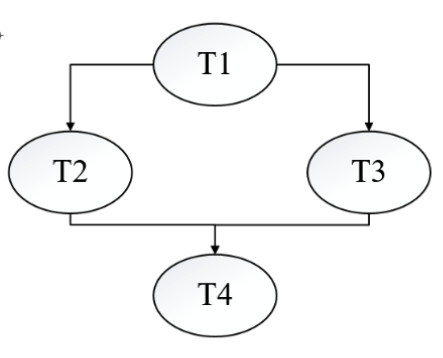

**INPUT:**
*   Không có

**OUTPUT:**
*   Trường hợp 1: Tên các tiến trình được in ra khi các tiến trình thực thi đồng thời và không có sự đồng bộ.
*   Trường hợp 2: Tên các tiến trình được in ra theo đúng thứ tự thực thi yêu cầu, trong đó: Tiểu trình T1 thực thi trước tiểu trình T2 và T3. Tiểu trình T4 thực thi sau tiểu trình T2 và T3.

**CÁCH TÍNH ĐIỂM:**
*   Source code và kết quả thực thi: **1 điểm/2 trường hợp**
*   Báo cáo giải thích về cách làm: **1 điểm/2 trường hợp**
*   Nhận xét về kết quả thực thi, chứng minh cách làm là đúng: **1 điểm**

**Mẫu thực thi:**

Trường hợp 1: Không đồng bộ

```
!./baitap2unsync

```

**Mẫu kết quả trả về:**

```
T1
T4
T3
T2

```
hoặc
```
T1
T2
T3
T4
```
hoặc
```
T1
T3
T4
T2
```
Trường hợp 2: Đồng bộ

```
!./baitap2sync

```

**Mẫu kết quả trả về:**

```
T1
T2
T3
T4

```
hoặc
```
T1
T3
T2
T4
```

## **Bài làm**

In [ ]:
%%writefile baitap2unsync.c
# Noi dung script
...

In [ ]:
%%writefile baitap2sync.c
# Noi dung script
...

### ***Giải thích cách thực hiện***

## **Kiểm thử**

In [ ]:
# Lưu ý thực hiện 3 testcases. Mỗi testcase mà một ô kết quả.
!gcc baitap2unsync.c -o baitap2unsync
!./baitap2unsync

In [ ]:
# Lưu ý thực hiện 2 testcases. Mỗi testcase mà một ô kết quả.
!gcc baitap2sync.c -o baitap2sync
!./baitap2sync

### ***Nhận xét kết quả***

# **Câu 3** | Tự đánh giá: .../4 điểm

*(sinh viên điền điểm tự đánh dựa trên quy tắc chấm điểm được cung cấp)*

## **Nội dung**

Cho một mảng `a` được khai báo toàn cục là một mảng số nguyên có thể chứa `n` phần tử. Viết chương trình bao gồm 2 thread chạy song song:
*   Một thread làm nhiệm vụ sinh ra một số nguyên ngẫu nhiên sau đó bỏ vào a. Sau đó đếm và xuất ra số phần tử của a có được ngay sau khi thêm vào.
*   Thread còn lại lấy ra một phần tử trong a (phần tử bất kỳ, phụ thuộc vào người lập trình). Sau đó đếm và xuất ra số phần tử của a có được ngay sau khi lấy ra, nếu không có phần tử nào trong a thì xuất ra màn hình “Khong con phan tu trong mang”.
Hiện thực mô hình trên với 2 trường hợp:
*   Trường hợp 1: Không đồng bộ, tìm và giải thích vấn đề xảy ra khi đồng bộ.
*   Trường hợp 2: Đồng bộ hóa và chứng minh các vấn đề trong trường hợp 1 đã được giải quyết.


**INPUT:**
*   Số phần tử tối đa trong mảng: `n`

**OUTPUT:**
*   Trường hợp 1: Đếm số lượng phần tử trong mảng và danh sách các phần tử khi không đồng bộ.
*   Trường hợp 2: Đếm số lượng phần tử trong mảng và danh sách các phần tử khi có đồng bộ.

**CÁCH TÍNH ĐIỂM:**
*   Source code và kết quả thực thi trường hợp 1: **1 điểm**
*   Nhận xét về kết quả thực thi và giải thích vấn đề xảy ra khi không đồng bộ: **1 điểm**
*   Source code và kết quả thực thi trường hợp 2: **1 điểm**
*   Báo cáo giải thích về cách đồng bộ: **0.5 điểm**
*   Nhận xét về kết quả thực thi, chứng minh cách làm là đúng: **0.5 điểm**

**Mẫu thực thi:**

Trường hợp 1: Không đồng bộ

```
!./baitap3unsync
# Không có kết quả mẫu, sinh viên tự thực hiện và giải thích vấn đề xảy ra.
```


Trường hợp 2: Đồng bộ

```
!./baitap3sync

```

**Mẫu kết quả trả về:**

```
Moi nhap so luong phan tu toi da: 5
ADDING   | Count = 1 | 4
ADDING   | Count = 2 | 4 2
ADDING   | Count = 3 | 4 2 7
ADDING   | Count = 4 | 4 2 7 9
ADDING   | Count = 5 | 4 2 7 9 1
REMOVING | Count = 4 | 2 7 9 1
REMOVING | Count = 3 | 7 9 1
REMOVING | Count = 2 | 9 1
REMOVING | Count = 1 | 1
REMOVING | Count = 0 | Khong con phan tu trong mang
ADDING   | Count = 1 | 9
ADDING   | Count = 2 | 9 2
ADDING   | Count = 3 | 9 2 5
REMOVING | Count = 2 | 2 5
REMOVING | Count = 1 | 2
ADDING   | Count = 2 | 2 7
...

```

## **Bài làm**

### ***Trường hợp 1***

In [ ]:
%%writefile baitap3unsync.c
# Noi dung script
...

### ***Trường hợp 2***

In [ ]:
%%writefile baitap3sync.c
# Noi dung script
...

### ***Giải thích cách thực hiện đồng bộ***

## **Kiểm thử**

### ***Trường hợp 1***

In [ ]:
# Lưu ý thực hiện 3 testcases. Mỗi testcase mà một ô kết quả.
!gcc baitap3unsync.c -o baitap3unsync
!./baitap3unsync

### ***Nhận xét và giải thích trường hợp không đồng bộ***

### ***Trường hợp 2***

In [ ]:
# Lưu ý thực hiện 2 testcases. Mỗi testcase mà một ô kết quả.
!gcc baitap3sync.c -o baitap3sync
!./baitap3sync

### ***Nhận xét về kết quả***